# CSCI 347 Project 02: Explorig Graph Data



Our Dataset:

In [4]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

G = nx.read_edgelist('aves-weaver-social-08.edges', create_using=nx.Graph(), nodetype=int)

TEST = nx.read_edgelist('facebook_combined.txt', create_using=nx.Graph(), nodetype=int)


# Problem 1


1. [4 points] Why did you choose this dataset, and why is it interesting to you? (Make sure you include
a link to the dataset that you chose).

__We chose this dataset since its size seemed manageable to work with and easy to visualize and understand. The dataset includes social information about weavers in South Africa. The graph’s edges represent birds using the same nest chambers. The social interactions of birds interested us.__
__https://networkrepository.com/aves-weaver-social-08.php__

2. [3 points] Did you preprocess the data? If so, how did you preprocess it? Clearly explain the process.
e.g., Did you take the largest connected component? Was it manageable, if not, did you sample it?
How did you take the sample of the graph? What did you do after sampling? Did you do any other
preprocessing? etc.

__We did not do any preprocessing. We chose a dataset that was connected and not too large to visualize.__

3. [2 points] Explain what type of data is represented in this dataset.

__The type of data represented in this data set is animal interaction data from published studies of wild, captive, and domesticated animals. The dataset defines an interaction by drawing a network edge between animals that used the same nest chambers either for roosting or nest-building. The data is collected from 23 colonies of sociable weavers.__

4. [6 points] Answer the following questions before doing the analysis.

- a. [2 points] What characteristic do you expect the 
    nodes  with high centrality to possess? E.g.,
    what type of non-graph characteristic would you expect the nodes with high centrality have?
    Note that this answer depends on the dataset that you choose.

__The characteristic that I expect nodes with high centrality to have would be weavers that commonly use other birds nesting chambers or share nesting chambers.__


- b. [2 points] Do you think this graph dataset would exhibit power law? State your reasons.

__I do not think this dataset would exhibit the power law. Our average degree is 10 and the maximum degree is 22, if the power law was exhibited in this data set then we would expect the maximum degree to be much larger than the average.__


- c. [2 points] Do you expect this graph to have small-world property? State your reasons

__Yes, since we have a density of 0.38 and an average clustering coefficient of 0.773. These numbers confirm that the clustering coefficient is significantly higher than the density. There is also a high chance for any other bird in the colony to reach another through just 1 or 2 hops because we have just 28 nodes but an average degree of 10.__

# Problem 2


1. [5 points] Implement a function that takes list of edges of a graph—represented as tuples—and output the number of nodes.

In [5]:
def num_nodes (edges): 
    nodes = set()
    for u, v in edges:
        nodes.add(u)
        nodes.add(v)
    return len(nodes)


2. [5 points] Implement a function that takes list of edges of a graph—represented as tuples—and an input vertex index as input and output the degree of the input vertex. 

In [6]:
def vertex_deg(edges, vertex):
    deg = 0
    for u, v in edges:
        if u == vertex or v == vertex:
            deg += 1
    return deg


3. [5 points] Implement a function that takes list of edges of a graph—represented as tuples—and output the adjacency matrix of the graph.

In [7]:
def adj_matrix(edges):
    n = num_nodes(edges)
    AM = [[0] * n for _ in range(n)]

    for u, v in edges:
        i, j = int(u), int(v)
        AM[i][j] = 1
        AM[j][i] = 1

    return AM


4. [5 points] Implement a function that takes list of edges of a graph—represented as tuples—and output the degree distribution of the graph. Output the degree distribution as a python list.

In [8]:
def deg_dist(edges):
    degree_count = {}
    for u, v in edges:
        degree_count[u] = degree_count.get(u, 0) + 1
        degree_count[v] = degree_count.get(v, 0) + 1

    max_degree = max(degree_count.values())
    degree_dist = [0] * (max_degree + 1)

    for degree in degree_count.values():
        degree_dist[degree] += 1

    return degree_dist


5. [5 points] Implement a function that takes degree distribution of a graph—represented as a list—and input degree, then output the probability of picking a vertex with degree higher than or equal to the input degree. 

In [9]:
def degree_probability(degree_distribution, n):
    if n < 1:
        return 1
    if n >= len(degrees):
        return 0
   
    return sum(degrees[n:]) / sum(degrees) if n != 0 else 0


6. [5 points] Implement a function that takes input vertex index, and a list of edges of a graph—represented as tuples—and output the eccentricity of the given vertex. 

In [10]:
def vertex_eccentricity_calc(vertex, edges):
    G = nx.Graph()
    G.add_edges_from(edges)


    distances = {vertex: 0}
    que = [vertex]
    while que:
        current = que.pop(0)
        for neighbor in G.neighbors(current):
            if neighbor not in distances:
                distances[neighbor] = distances[current] + 1
                que.append(neighbor)
    return max(distances.values())

7. [5 points] Implement a function that takes list of edges of a graph—represented as tuples—and output the diameter of the graph. (you can use networkx function to find the shortest path between two vertices)

In [11]:
def diameter_calc(edges):
    G = nx.Graph()
    G.add_edges_from(edges)


    eccentricities = {}
    for vertex in G.nodes():
        eccentricities[vertex] = vertex_eccentricity_calc(vertex, edges)
    return max(eccentricities.values())


8. [5 points] Implement a function that takes list of edges of a graph—represented as tuples—and output the radius of the graph. (you can use networkx function to find the shortest path between two vertices)

In [12]:
def radius_calc(edges):
    G = nx.Graph()
    G.add_edges_from(edges)


    eccentricities = {}
    for vertex in G.nodes():
        eccentricities[vertex] = vertex_eccentricity_calc(vertex, edges)
    return min(eccentricities.values())


9. [5 points] Implement a function that takes vertex index and a list of edges of a graph—represented as tuples—and output the clustering coefficient of the input vertex. 



In [13]:
def clustering_coefficient(edges, vertex):
    edge_set = set()
    for u, v in edges:
        edge_set.add(tuple(sorted((u, v))))

    neighbors = set()
    for u, v in edges:
        if u == vertex:
            neighbors.add(v)
        elif v == vertex:
            neighbors.add(u)
    
    k = len(neighbors)
    if k < 2:
        return 0.0
    
    actual_links = 0
    neighbor_list = list(neighbors)
    for i in range(len(neighbor_list)):
        for j in range(i + 1, len(neighbor_list)):
            if tuple(sorted((neighbor_list[i], neighbor_list[j]))) in edge_set:
                actual_links += 1
    
    return (2.0 * actual_links) / (k * (k - 1))


10. [5 points] Implement a function that takes a vertex index and a list of edges of a graph—represented as tuples—and output the betweenness centrality of the input vertex.

In [14]:
def betweenness_centrality(vertex, edges):
    G = nx.Graph()
    G.add_edges_from(edges)
    nodes = list(G.nodes())
    n = len(nodes)
    betweenness = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            s = nodes[i]
            t = nodes[j]
            
            if s == vertex or t == vertex:
                continue
            
            all_paths = list(nx.all_shortest_paths(G, source=s, target=t))
            num_paths = len(all_paths)
            
            paths_thru_v = 0 
            for path in all_paths:
                if vertex in path: 
                    paths_thru_v += 1 
            betweenness += (paths_thru_v / num_paths)

    return betweenness


11. [5 points] Implement a function that takes a vertex index and a list of edges of a graph—represented as tuples—and output the closedness centrality of the input vertex. 


In [15]:
def closedness_centrality(vertex, edges):
    G = nx.Graph()
    G.add_edges_from(edges)
    
    lengths = nx.single_source_shortest_path_length(G, vertex)
    total_distance = 0
    for node in lengths:
        total_distance += lengths[node]
    
    n = len(G.nodes())
    num_others = n - 1
    if total_distance > 0:
        return num_others / total_distance
    
    return 0.0


12. [5 points] Implement power iteration to find the eigenvector centrality of each node in a network. But there is a slight difference in the implementation. Instead of using 𝐿∞ norm for normalizing the resultant vector at each iteration use 𝐿2(Euclidean distance) for normalization. You may use numpy matrix multiplication library functions, transpose function, dot product functions, norm functions but you may not use the libraries to directly calculate eigenvectors. You may assume that the inputs to this function are the adjacency matrix and max number of iterations. 


In [16]:
def eigenvector_centrality(adjacency_matrix, max_iterations):
    num_nodes = adjacency_matrix.shape[0]
    centrality_vector = np.ones(num_nodes)
    for i in range(max_iterations):
        new_vector = np.dot(adjacency_matrix, centrality_vector)
        
        v_norm = np.linalg.norm(new_vector)
        if v_norm == 0:
            break
        new_vector = new_vector / v_norm
        
        if np.linalg.norm(new_vector - centrality_vector) < 1e-6:
            centrality_vector = new_vector
            break
        centrality_vector = new_vector
        
    return centrality_vector.tolist()


# Problem 3


1. [5 points] Provide a visualization of the graph dataset that you chose. If the dataset is too large, you may visualize a sample of the graph. 


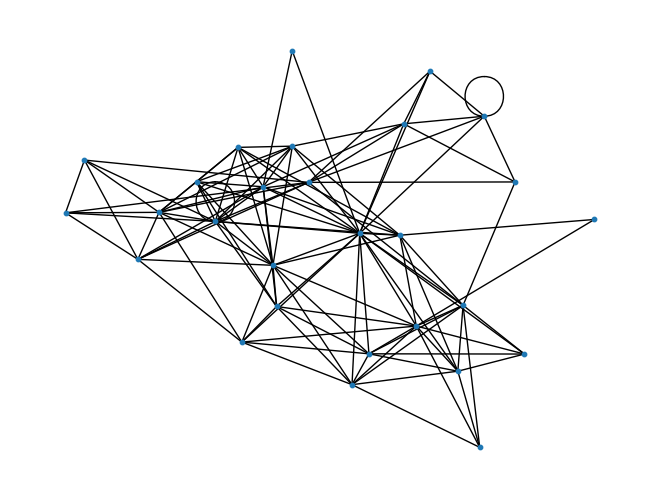

In [17]:
nx.draw(G, node_size=10)

2. [3 points] List the 10 nodes with highest closedness centrality.


In [18]:
closeness = nx.closeness_centrality(G)
top10_closeness = pd.Series(closeness).nlargest(10)
print(top10_closeness)


135    0.771429
151    0.658537
139    0.642857
153    0.627907
143    0.613636
145    0.613636
147    0.613636
133    0.586957
152    0.586957
157    0.586957
dtype: float64


3. [3 points] List the 10 nodes with highest betweenness centrality. 

In [19]:
betweenness = nx.betweenness_centrality(G)
top10_betweenness = pd.Series(betweenness).nlargest(10)
print(top10_betweenness)


135    0.243698
133    0.084904
143    0.078763
139    0.075480
145    0.063185
147    0.061904
151    0.055738
153    0.045470
138    0.035181
136    0.021655
dtype: float64


4. [3 points] List the 10 nodes with highest clustering coefficients

In [20]:
coefficients = nx.clustering(G)
top_10 = sorted(coefficients, key=coefficients.get, reverse=True)[:10]
print(top_10)

[137, 141, 144, 149, 154, 159, 158, 155, 132, 157]


5. [3 points] Find the top 10 nodes ranked by the highest prestige/eigenvector centrality. 

In [21]:
prestiges = nx.eigenvector_centrality(G)
top_10 = sorted(prestiges, key=prestiges.get, reverse=True)[:10]
print(top_10)



[135, 151, 139, 153, 147, 145, 152, 157, 138, 158]


6. [3 points] List the top 10 nodes ranked by PageRank.

In [22]:
page_ranks = nx.pagerank(G)
top_10 = sorted(page_ranks, key=page_ranks.get, reverse=True)[:10]
print(top_10)



[135, 139, 151, 145, 153, 138, 133, 143, 147, 146]


7. [4 points] Go through your answers on Problem 3 [2-6] sub questions. Are these highly ranked nodes based on different centrality measurements the same or different? If there is a difference, is it significant or not? Why do you think this is the case? 

__Most are similar but not all, node 133 for example. Although the two outputs share members, the difference in rank is significant. A bird might have a high closedness because it lives in a high-density area, but may still have a lower betweenness.__


8. [3 points] Plot the log-log plot of the degree distribution of the graph—make sure that x-axis is the log 𝑘 and y-axis is the log 𝑓(𝑘), where 𝑓(𝑘) is the probability that a random node we pick has degree 𝑘. Make sure you draw the least-square fit line of the given data points as well. By looking at the plot, do you think the graph exhibits power-law behavior? 


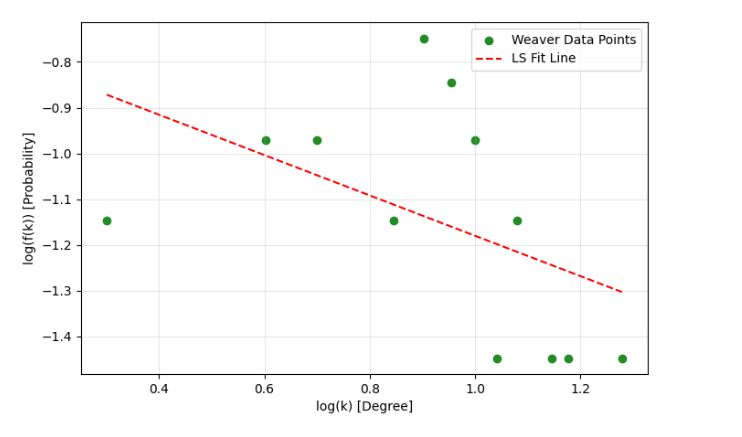

__This graph does not appear to exhibit power-law behavior. It lacks the long tail that would indicate it, and the plot lacks a clear linear makeup.__